In [31]:
import numpy as np
import pandas as pd
import MDAnalysis as mda
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from tqdm.auto import trange


In [59]:
def distances_from_multistate_pdb(pdb_file, atomid1=644, atomid2=997):
    u = mda.Universe(pdb_file)
    dists = []

    a1 = u.select_atoms(f"id {atomid1}")
    a2 = u.select_atoms(f"id {atomid2}")
  #  if len(a1) != 1 or len(a2) != 1:
  #      raise ValueError("Expected exactly one atom for each atom id.")
    #print(len(a1.positions))
    #print(a1.positions)
    for i in range(len(a1.positions)):
        d = np.linalg.norm(a1.positions[i] - a2.positions[i])
#        print(d)   
        dists.append(float(d))

    return dists

In [60]:
def bootstrap_kde(
    dk_replicas: list[list[float]],
    output_csv: str,
    n_bootstrap: int = 4000,
    confidence_level: float = 95,
    x_min: float = 2,
    x_max: float = 12,
    n_points: int = 100,
    bw_scale: float = 0.6
):
    dk_all = [item for sublist in dk_replicas for item in sublist]
    x_grid = np.linspace(x_min, x_max, n_points)

    kde_samples = np.zeros((n_bootstrap, len(x_grid)))
    print("len(dk_replicas):", len(dk_replicas))
    print("len(dk_replicas[0]):", len(dk_replicas[0]))
    print("first few values:", dk_replicas[0][:5])
    for i in trange(n_bootstrap, desc="Bootstrap KDE"):
        sample = np.random.choice(dk_all, size=len(dk_all), replace=True)
        kde = gaussian_kde(sample)
        kde.set_bandwidth(bw_method=kde.factor * bw_scale)
        kde_samples[i, :] = kde(x_grid)

    lower_bound = np.percentile(kde_samples, (100 - confidence_level) / 2, axis=0)
    upper_bound = np.percentile(kde_samples, 100 - (100 - confidence_level) / 2, axis=0)
    kde_mean = np.mean(kde_samples, axis=0)
    kde_std = np.std(kde_samples, axis=0)

    df_out = pd.DataFrame({
        "x": x_grid,
        "kde_mean": kde_mean,
        "kde_std": kde_std,
        "ci_lower": lower_bound,
        "ci_upper": upper_bound
    })
    df_out.to_csv(output_csv, index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, kde_mean, label="mean KDE")
    plt.fill_between(
        x_grid,
        lower_bound,
        upper_bound,
        alpha=0.3,
        label=f"CI {confidence_level}%"
    )
    plt.xlabel("distance")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_out

len(dk_replicas): 1
len(dk_replicas[0]): 200
first few values: [7.342944622039795, 7.280485153198242, 7.2513322830200195, 7.298089504241943, 7.325056552886963]


Bootstrap KDE:   0%|          | 0/4000 [00:00<?, ?it/s]

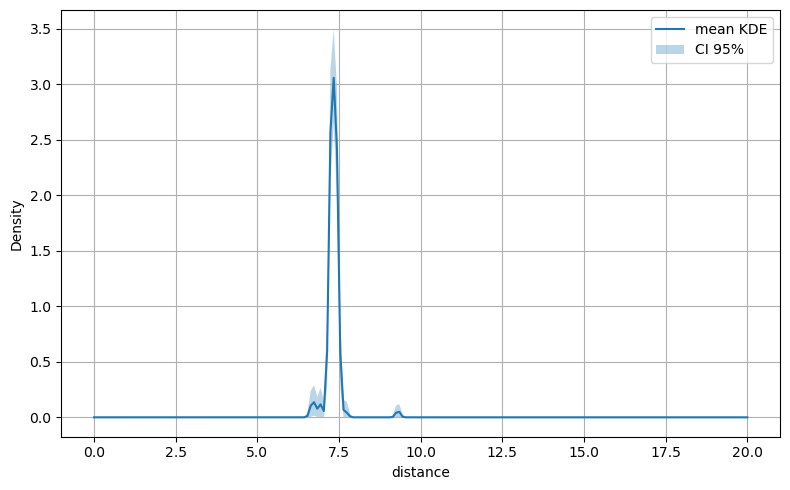

In [69]:
#dkreplicas = [distances_from_multistate_pdb("aligned_glca.pdb", 644, 997)]
#dkreplicas = [distances_from_multistate_pdb("aligned_glc.pdb", 644, 972)]
#dkreplicas = [distances_from_multistate_pdb("aligned_gala.pdb", 644, 972)]
dkreplicas = [distances_from_multistate_pdb("aligned_gal.pdb", 644, 972)]
#dkreplicas = [distances_from_multistate_pdb("aligned_glcnac.pdb", 644, 987)]
#dkreplicas = [distances_from_multistate_pdb("aligned_galnac.pdb", 644, 987)]


df_kde = bootstrap_kde(
    dkreplicas,
    output_csv="output/bootstrap_kde_gal.csv",
    n_bootstrap=4000,
    confidence_level=95,
    x_min=0.0,
    x_max=20.0,
    n_points=200,
    bw_scale=0.6,
)